# 01: Coverage

*How completely does each knowledge graph represent the biomedical entities and relations relevant to drug repurposing?*

**Entity coverage** = |KG ∩ gold| / |gold| per type (drugs: DrugBank · genes: UniProt/Entrez · diseases: Disease Ontology · pathways: Reactome). **Relation coverage** = the same for gold pairs (drug–target: DrugBank · drug–disease: Open Targets · drug–drug: DrugBank). The dimension score is their equal-weighted mean over types shared by all KGs.

**Inputs:** `config.yaml` · `data/gold_standards/`
**Outputs:** `results/figures/01_{entity,relation}_coverage.{pdf,png}` · `results/checkpoints/01_coverage.pkl`

## Set-up

KGs and gold-standard reference sets load from paths in `config.yaml` and `data/gold_standards/` (DrugBank, UniProt, Disease Ontology, Reactome, Open Targets, MESH–DOID bridge). Coverage is computed exactly over the full sets — no sampling.

In [1]:
# Imports
import sys, os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import Optional

_root = Path(os.path.abspath('')).resolve()
_root = _root.parent if _root.name == 'eval_notebooks' else _root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from src.plotting import setup_style, save_fig, TEXT_COLOR, TICK_COLOR, KG_PALETTE, HEATMAP_CMAP
from src.loading  import find_config, load_config, load_kg

setup_style()


In [2]:
# Config and paths
config = load_config(find_config(_root))
params = config['analysis_params']
BASE   = config['_base_dir']
GOLD   = BASE / 'data' / 'gold_standards'
FIGS   = BASE / 'results' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

def _style_left_spine(ax):
    """Hide top/right/bottom spines; style left spine for clean axis presentation."""
    for sp in ('top', 'right', 'bottom'):
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['left'].set_linewidth(0.5)


### Loading

In [3]:
# Load KGs - skips any not found or erroring gracefully
kgs = {}
for name in config['knowledge_graphs']:
    try:
        kg, nodes = load_kg(name, config)
        kgs[name] = {'kg': kg, 'nodes': nodes}
        print(f'{name:12s}: {len(kg):>12,} edges  {len(nodes):>8,} nodes  '
              f'{kg["relation"].nunique():>4} relation types')
    except FileNotFoundError:
        print(f'{name:12s}: [NOT FOUND]')
    except Exception as e:
        print(f'{name:12s}: [ERROR] {e}')

KG_NAMES = list(kgs.keys())

primekg     :    8,100,498 edges   129,375 nodes    30 relation types
hetionet    :    2,250,197 edges    47,031 nodes    24 relation types
drkg        :    5,874,261 edges    97,238 nodes   107 relation types
openbilink  :    4,986,521 edges   185,929 nodes    28 relation types
biokg       :    2,067,998 edges   105,524 nodes    17 relation types
  matrix: loading from cache _cache_matrix_88f004a4_kg.parquet / _cache_matrix_88f004a4_nodes.parquet
  matrix: cached load — 2,850,122 nodes, 41,595,079 edges
matrix      :   41,595,079 edges  2,850,122 nodes    76 relation types


In [4]:
# KG metadata derived from config - drives all downstream cells
ENTITY_TYPE_MAP = {n: config['knowledge_graphs'][n].get('entity_types', {}) for n in KG_NAMES}
KG_RELATIONS    = {n: config['knowledge_graphs'][n].get('relations',     {}) for n in KG_NAMES}
PATHWAY_KGS     = {n for n in KG_NAMES
                   if config['knowledge_graphs'][n].get('pathway_ontology') == 'reactome'}
KG_COLORS       = {n: KG_PALETTE.get(n, '#888888') for n in KG_NAMES}


## 1. Entity Coverage

$$\text{Entity Coverage}_t = \frac{|\text{KG}_t \cap \text{Gold}_t|}{|\text{Gold}_t|}$$

for entity type $t$ (Drug, Disease, Gene/Protein, Pathway). IDs are normalised per `config.yaml`: drugs (DrugBank) and genes (Entrez) match natively; diseases normalise to DOID; pathways (Reactome) apply only to KGs with `pathway_ontology: reactome`.

### Gold standards

Reference sets are loaded once and shared across types: drugs/genes match natively, diseases normalise per-KG, pathways apply only to Reactome KGs.

In [5]:
# Utility helpers - ID normalisation and coverage calculation

def _as_str_set(series: pd.Series) -> set:
    """Series -> normalised string set (strips whitespace, drops nulls and empty strings)."""
    return set(series.dropna().astype(str).str.strip()) - {''}

def _strip_prefix(id_str: str) -> str:
    """Strip type prefix: 'Compound::DB00001' -> 'DB00001'."""
    s = str(id_str).strip()
    return s.split('::')[-1] if '::' in s else s

def entity_set_from_kg(kg: pd.DataFrame, entity_type: str) -> set:
    """Unique bare node IDs for entity_type from an edge table."""
    raw = _as_str_set(pd.concat([
        kg.loc[kg['x_type'] == entity_type, 'x_id'],
        kg.loc[kg['y_type'] == entity_type, 'y_id'],
    ], ignore_index=True))
    return {_strip_prefix(i) for i in raw}

def calc_coverage(kg_set: set, gold_set: set) -> dict:
    """Coverage = |KG & Gold| / |Gold|."""
    overlap = kg_set & gold_set
    n_gold  = len(gold_set)
    return {
        'kg_n':         len(kg_set),
        'gold_n':       n_gold,
        'overlap_n':    len(overlap),
        'coverage_pct': round(100 * len(overlap) / n_gold, 2) if n_gold else float('nan'),
        'matched':      overlap,
        'unmatched':    gold_set - kg_set,
    }


In [6]:
# Gold standard reference sets
drugbank     = pd.read_csv(GOLD / 'drugbank_drugs.csv',               low_memory=False)
drugbank_ddi = pd.read_csv(GOLD / 'drugbank_ddi.csv')
do           = pd.read_csv(GOLD / 'do_diseases.csv')
mesh_doid_df = pd.read_csv(GOLD / 'mesh_to_doid.csv',                on_bad_lines='skip')
uniprot      = pd.read_csv(GOLD / 'uniprot_genesproteins.csv',        low_memory=False)
reactome     = pd.read_csv(GOLD / 'reactome_pathways.csv')
ot_ind       = pd.read_csv(GOLD / 'opentargets_drug_indications.csv', low_memory=False)

# ── Drugs ─────────────────────────────────────────────────────────────────────
# Approved and investigational only for entity/relation coverage gold standard.
# _db_all_ids retains the full set for DDI (which spans all statuses in DrugBank).
drugbank_relevant = drugbank[drugbank['is_approved'] | drugbank['is_investigational']]
gold_drugs        = _as_str_set(drugbank_relevant['drugbank_id'])
_db_all_ids       = _as_str_set(drugbank['drugbank_id'])

# ── Diseases — DOID numeric strings ──────────────────────────────────────────
gold_diseases_doid = set(
    do['doid'].str.replace('DOID:', '', regex=False).str.lstrip('0')
) - {''}

# ── MONDO <-> DOID bridge (many-to-many in both directions) ──────────────────
from collections import defaultdict as _ddict   # single import

_do_clean = do.dropna(subset=['mondo_id', 'doid']).copy()
_do_clean['mondo_num'] = (
    _do_clean['mondo_id']
    .str.replace('MONDO:', '', regex=False)
    .str.lstrip('0')
    .replace({'': '0'})          # FIX: dict-form replace handles empty strings
)
_do_clean['doid_num'] = (
    _do_clean['doid']
    .str.replace('DOID:', '', regex=False)
    .str.lstrip('0')
    .replace({'': '0'})          # FIX: same here
)

# Forward: MONDO numeric -> sorted list of DOID numerics (many-to-many)
mondo_to_doid_all = _ddict(set)
for _, r in _do_clean.iterrows():
    mondo_to_doid_all[r['mondo_num']].add(r['doid_num'])
mondo_to_doid_all = {k: sorted(v) for k, v in mondo_to_doid_all.items()}

# Backwards-compatible 1:1 dict (first DOID per MONDO, sorted)
mondo_to_doid = {k: vs[0] for k, vs in mondo_to_doid_all.items()}

# Reverse: DOID numeric -> list of MONDO numerics.
# FIX: iterate mondo_to_doid_all (not the collapsed 1:1 dict) so every
# MONDO that maps to a given DOID is captured, not just the "first-wins" one.
_doid_to_mondos = _ddict(list)
for _mk, _dvs in mondo_to_doid_all.items():
    for _dv in _dvs:
        _doid_to_mondos[_dv].append(_mk)

doid_to_mondo     = {d: ms[0] for d, ms in _doid_to_mondos.items()}  # first-wins compat
doid_to_mondo_all = dict(_doid_to_mondos)                             # full one-to-many

# ── MESH -> DOID bridge ───────────────────────────────────────────────────────
# Prefer DO-sourced mappings over MONDO; deduplicate on clean MESH ID.
mesh_doid_df['mesh_id_clean'] = (
    mesh_doid_df['mesh_id']
    .str.replace(r'\s*\{.*\}', '', regex=True)
    .str.strip()
)
_mesh_dedup = (
    mesh_doid_df
    .assign(src_rank=mesh_doid_df['source'].map({'DO': 0, 'MONDO': 1}).fillna(2))
    .sort_values('src_rank')
    .drop_duplicates(subset='mesh_id_clean', keep='first')
)
mesh_to_doid = {
    r['mesh_id_clean']: (r['doid'].replace('DOID:', '').lstrip('0') or '0')
    for _, r in _mesh_dedup.iterrows() if pd.notna(r['doid'])
}

# ── Genes — Entrez IDs ────────────────────────────────────────────────────────
# Split semicolon-delimited multi-ID entries; each part is a valid Entrez ID.
gold_genes = {
    g.strip()
    for val in uniprot['GeneID'].dropna().astype(str)
    for g in val.split(';') if g.strip()
}

# ── Pathways — Reactome R-HSA-* IDs ──────────────────────────────────────────
gold_pathways = _as_str_set(reactome['reactome_id'])


In [7]:
import re as _re

def get_disease_ids_doid(kg: pd.DataFrame, kg_name: str) -> set:
    """Return disease IDs normalised to DOID numeric strings.

    Reads 'disease_id_scheme' from config per KG:
      'mondo'     - MONDO numerics; bridged via mondo_to_doid_all.
                    'disease_id_separator' splits compound IDs.
      'doid'      - IDs carry 'DOID:' prefix; strip to numeric.
                    Non-DOID IDs are counted and warned about.
      'doid_mesh' - mixed 'DOID:'/'MESH:'; MESH bridged via mesh_to_doid.
      'mesh'      - bare MeSH IDs (D*, C*); bridged via MESH:{id}->DOID.
    """
    cfg    = config['knowledge_graphs'][kg_name]
    scheme = cfg.get('disease_id_scheme', 'doid')
    sep    = cfg.get('disease_id_separator')
    raw    = entity_set_from_kg(kg, ENTITY_TYPE_MAP[kg_name]['Disease'])

    if scheme == 'mondo':
        # Emit ALL DOIDs for each MONDO part (handles many-to-many)
        result = set()
        for i in raw:
            for p in (str(i).split(sep) if sep else [str(i)]):
                mkey = p.strip().lstrip('0') or '0'
                for doid in mondo_to_doid_all.get(mkey, []):
                    result.add(doid)
        return result

    if scheme == 'doid':
        matched   = {i.replace('DOID:', '').lstrip('0') for i in raw if i.startswith('DOID:')}
        n_dropped = sum(1 for i in raw if not i.startswith('DOID:'))
        if n_dropped:
            print(f'  [{kg_name}] doid scheme: {n_dropped:,} non-DOID IDs silently dropped '
                  f'(check entity_type mapping in config)')
        return matched

    if scheme == 'doid_mesh':
        return (
            {i.replace('DOID:', '').lstrip('0') for i in raw if i.startswith('DOID:')} |
            {mesh_to_doid[i] for i in raw if i.startswith('MESH:') and i in mesh_to_doid}
        )

    if scheme == 'mesh':
        # BioKG: bare MeSH IDs (e.g. D001234, C012345) — prepend MESH: for lookup
        return {
            mesh_to_doid[f'MESH:{i}']
            for i in raw
            if f'MESH:{i}' in mesh_to_doid
        }

    raise ValueError(f'Unknown disease_id_scheme for {kg_name!r}: {scheme!r}')

# Compiled pattern for bare MeSH IDs: D or C followed by digits only.
# FIX: replaces the too-broad heuristic that matched gene symbols like CDK2.
_BARE_MESH_RE = _re.compile(r'^[DC]\d+$')

def _to_mondo(id_str: str) -> Optional[str]:
    """Map DOID:*, MESH:*, or bare MeSH ID to MONDO numeric string via bridge tables.

    Returns the first matching MONDO ID (for backwards compat).
    Bare MeSH IDs are matched only if they conform to the strict D/C + digits
    pattern to avoid false matches on gene symbols (e.g. CDK2, DNMT3A).
    """
    s = str(id_str).strip()
    if s.startswith('DOID:'):
        doid_num = s.replace('DOID:', '').lstrip('0') or '0'
        mondos = doid_to_mondo_all.get(doid_num, [])
        return mondos[0] if mondos else None
    if s.startswith('MESH:'):
        doid_num = mesh_to_doid.get(s)
        if doid_num:
            mondos = doid_to_mondo_all.get(doid_num, [])
            return mondos[0] if mondos else None
        return None
    # BioKG: bare MeSH IDs (D*, C*) — strict pattern match before bridging
    if _BARE_MESH_RE.match(s):                   # FIX: was too broad
        doid_num = mesh_to_doid.get(f'MESH:{s}')
        if doid_num:
            mondos = doid_to_mondo_all.get(doid_num, [])
            return mondos[0] if mondos else None
    return None


### Coverage computation

Entity sets are extracted per KG, normalised to canonical IDs, and intersected with the gold standard; per-entity membership CSVs are exported.

In [8]:
# Extract entity sets per KG
# OpenBioLink uses CURIE-prefixed IDs that must be normalised before matching gold standards:
#   PUBCHEM.COMPOUND:* drugs  -> DrugBank accession via pubchem_to_drugbank mapping
#   NCBIGENE:* genes          -> bare Entrez IDs (strip NCBIGENE: prefix)
#   REACTOME:* paths          -> bare R-HSA-* IDs (strip REACTOME: prefix only;
#                                KEGG:* IDs are excluded — incommensurable with Reactome gold)
# BioKG uses UniProt accessions for genes -> bridge to Entrez IDs via uniprot gold standard.
# NOTE: BioKG gene coverage is a lower bound. The UniProt->Entrez bridge accepts only
# unambiguous 1:1 mappings (single GeneID per UniProt entry). Multi-gene UniProt entries
# (~15% of the proteome) are excluded, which depresses BioKG gene coverage relative to
# KGs that use Entrez IDs natively. See normalisation pipeline table for raw vs normalised counts.
PRINT_ENTITIES = ['Drug', 'Disease', 'Gene/Protein', 'Pathway']

# Build PubChem -> DrugBank lookup from the openbilink nodes table
_obl_pc_to_db = {}
if 'openbilink' in kgs:
    _obl_nodes = kgs['openbilink']['nodes']
    _drug_mask  = (_obl_nodes['type'] == 'Drug') & _obl_nodes['drugbank_id'].str.startswith('DB', na=False)
    _obl_pc_to_db = dict(zip(_obl_nodes.loc[_drug_mask, 'id'],
                             _obl_nodes.loc[_drug_mask, 'drugbank_id']))

# Build UniProt -> Entrez lookup for BioKG (gold standard has Entry -> GeneID mapping)
_uniprot_to_entrez = {}
if 'biokg' in kgs:
    for _, row in uniprot.iterrows():
        acc     = str(row.get('Entry', '')).strip()
        gid_raw = str(row.get('GeneID', '')).strip().rstrip(';')
        gids    = [g.strip() for g in gid_raw.split(';') if g.strip()]
        # Only accept unambiguous 1:1 mappings (reject multi-gene entries)
        if acc and len(gids) == 1 and gids[0].isdigit():
            _uniprot_to_entrez[acc] = gids[0]

entity_sets = {}
for kg_name, data in kgs.items():
    kg, emap = data['kg'], ENTITY_TYPE_MAP[kg_name]
    sets = {}
    for canonical, kg_type in emap.items():
        if canonical == 'Disease':
            sets[canonical] = get_disease_ids_doid(kg, kg_name)
        elif kg_name == 'openbilink':
            raw = entity_set_from_kg(kg, kg_type)
            if canonical == 'Drug':
                sets[canonical] = {_obl_pc_to_db[i] for i in raw if i in _obl_pc_to_db}
            elif canonical == 'Gene/Protein':
                sets[canonical] = {i.split(':', 1)[1] if i.startswith('NCBIGENE:') else i
                                   for i in raw}
            elif canonical == 'Pathway':
                # FIX: keep only REACTOME: IDs; KEGG: IDs are incommensurable with
                # the Reactome gold standard and must not inflate kg_n.
                sets[canonical] = {
                    i.split(':', 1)[1]
                    for i in raw
                    if i.startswith('REACTOME:')
                }
                n_kegg = sum(1 for i in raw if i.startswith('KEGG:'))
                if n_kegg:
                    print(f'  [openbilink] Pathway: {n_kegg:,} KEGG IDs excluded '
                          f'(incommensurable with Reactome gold standard)')
            else:
                sets[canonical] = raw
        elif kg_name == 'biokg' and canonical == 'Gene/Protein':
            raw = entity_set_from_kg(kg, kg_type)
            sets[canonical] = {_uniprot_to_entrez[i] for i in raw if i in _uniprot_to_entrez}
        else:
            sets[canonical] = entity_set_from_kg(kg, kg_type)
    entity_sets[kg_name] = sets
    summary = '  '.join(
        f'{e.lower()}={len(entity_sets[kg_name][e]):,}'
        for e in PRINT_ENTITIES
        if e in entity_sets[kg_name]
    )


OpenBioLink: 5,358 PubChem CIDs mapped to DrugBank accessions
BioKG: 18,984 UniProt accessions mapped to Entrez Gene IDs (1:1 only; multi-gene entries excluded — gene coverage is a lower bound)

primekg: drug=7,957  disease=11,204  gene/protein=27,610  pathway=2,516
hetionet: drug=1,538  disease=136  gene/protein=19,145  pathway=1,822
drkg: drug=24,313  disease=2,726  gene/protein=39,220  pathway=1,822
  [openbilink] Pathway: 503 KEGG IDs excluded (incommensurable with Reactome gold standard)
openbilink: drug=5,358  disease=9,503  gene/protein=19,902  pathway=1,860
biokg: drug=8,805  disease=3,549  gene/protein=16,119  pathway=14,779
matrix: drug=1,719,130  disease=11,718  gene/protein=842,553  pathway=115,809


In [9]:
# Gold standard sets and ID column labels for export
GOLD_SETS = {
    'Drug':         gold_drugs,
    'Disease':      gold_diseases_doid,
    'Gene/Protein': gold_genes,
    'Pathway':      gold_pathways,
}
ID_COL = {
    'Drug':         'drugbank_id',
    'Disease':      'doid_id',
    'Gene/Protein': 'entrez_id',
    'Pathway':      'reactome_id',
}


In [10]:
# Coverage calculation - KG x entity type
def _eligible(kg_name: str, entity_type: str) -> bool:
    """Pathway coverage only valid for KGs using Reactome ontology."""
    return not (entity_type == 'Pathway' and kg_name not in PATHWAY_KGS)

coverage_records, membership = [], {}
for kg_name, sets in entity_sets.items():
    for entity_type, kg_set in sets.items():
        if entity_type not in GOLD_SETS or not _eligible(kg_name, entity_type):
            continue
        res = calc_coverage(kg_set, GOLD_SETS[entity_type])
        coverage_records.append({
            'KG':            kg_name,
            'Entity Type':   entity_type,
            'KG Entities':   res['kg_n'],
            'Gold Standard': res['gold_n'],
            'Overlap':       res['overlap_n'],
            'Coverage (%)':  res['coverage_pct'],
        })
        membership.setdefault(entity_type, {})[kg_name] = res

entity_summary = pd.DataFrame(coverage_records)


In [11]:
# Normalisation pipeline - raw -> normalised -> matched -> coverage
mapping_rows = []
for kg_name in KG_NAMES:
    kg, emap = kgs[kg_name]['kg'], ENTITY_TYPE_MAP[kg_name]
    for entity_type, gold_set in GOLD_SETS.items():
        kg_type = emap.get(entity_type)
        if not kg_type or not _eligible(kg_name, entity_type):
            continue
        raw_ids  = entity_set_from_kg(kg, kg_type)
        norm_ids = entity_sets[kg_name].get(entity_type, set())
        matched  = norm_ids & gold_set
        mapping_rows.append({
            'KG':           kg_name,
            'Entity':       entity_type,
            'Raw nodes':    len(raw_ids),
            'Normalised':   len(norm_ids),
            'Matched gold': len(matched),
            'Gold size':    len(gold_set),
            'Coverage (%)': round(100 * len(matched) / len(gold_set), 2)  # FIX: 2dp to match calc_coverage
                            if gold_set else float('nan'),
        })

pd.DataFrame(mapping_rows).set_index(['KG', 'Entity'])


Raw nodes  Normalised  Matched gold  Gold size  \
KG         Entity                                                         
primekg    Drug               7957        7957          4388      10909   
           Disease           17080       11204         11204      11932   
           Gene/Protein      27610       27610         19088      19276   
           Pathway            2516        2516          2483       2830   
hetionet   Drug               1538        1538          1486      10909   
           Disease             136         136           135      11932   
           Gene/Protein      19145       19145         18804      19276   
drkg       Drug              24313       24313          5311      10909   
           Disease            5103        2726          2713      11932   
           Gene/Protein      39220       39220         18950      19276   
openbilink Drug              78592        5358          2620      10909   
           Disease            9510        9503          9405      11932   
           Gene/Protein      19902       19902         18940      19276   
           Pathway            2363        1860          1794       2830   
biokg      Drug               8805        8805          4677      10909   
           Disease            5812        3549          3537      11932   
           Gene/Protein      59204       16119         16119      19276   
           Pathway           14779       14779          1959       2830   
matrix     Drug            1719130     1719130          7972      10909   
           Disease           25861       11718         11718      11932   
           Gene/Protein     842553      842553         19275      19276   
           Pathway          115809      115809          2200       2830   

                         Coverage (%)  
KG         Entity                      
primekg    Drug                 40.22  
           Disease              93.90  
           Gene/Protein         99.02  
           Pathway              87.74  
hetionet   Drug                 13.62  
           Disease               1.13  
           Gene/Protein         97.55  
drkg       Drug                 48.68  
           Disease              22.74  
           Gene/Protein         98.31  
openbilink Drug                 24.02  
           Disease              78.82  
           Gene/Protein         98.26  
           Pathway              63.39  
biokg      Drug                 42.87  
           Disease              29.64  
           Gene/Protein         83.62  
           Pathway              69.22  
matrix     Drug                 73.08  
           Disease              98.21  
           Gene/Protein         99.99  
           Pathway              77.74

### Diagnostic: entity coverage gaps

Curator aids (not scored): cross-KG overlap — how many KGs cover each gold entity — and a sample of missing IDs per KG, to separate ID-mapping failures from genuine absence.

In [12]:
# Cross-KG overlap: how many gold entities are covered by 0, 1, 2, ... KGs
import random

# Seed is set here and again at the top of the missing-sample cell so that
# each cell produces stable output regardless of run order.
_RANDOM_SEED = params.get('random_seed', 42)
random.seed(_RANDOM_SEED)

N_SAMPLE_MISSING = 10

overlap_rows = []
for entity_type, gold_set in GOLD_SETS.items():
    eligible_kgs = [kg for kg in KG_NAMES if _eligible(kg, entity_type)]
    if not eligible_kgs:
        continue

    coverage_count = {}
    for gid in gold_set:
        n_covered = sum(
            1 for kg in eligible_kgs
            if kg in membership.get(entity_type, {})
            and gid in membership[entity_type][kg]['matched']
        )
        coverage_count[gid] = n_covered

    for n in range(len(eligible_kgs) + 1):
        ids_at_n = [gid for gid, c in coverage_count.items() if c == n]
        overlap_rows.append({
            'Entity Type': entity_type,
            'Covered by':  f'{n}/{len(eligible_kgs)} KGs',
            'Count':       len(ids_at_n),
            '% of Gold':   round(100 * len(ids_at_n) / len(gold_set), 1),
        })

overlap_df = pd.DataFrame(overlap_rows)
for et in GOLD_SETS:
    sub = overlap_df[overlap_df['Entity Type'] == et]
    if sub.empty:
        continue
    for _, row in sub.iterrows():
        bar = '█' * int(row['% of Gold'] / 5)


Cross-KG coverage overlap (gold-standard entities)

  Drug:
         0/6 KGs    2,302  ( 21.1%)  ████
         1/6 KGs    3,139  ( 28.8%)  █████
         2/6 KGs      672  (  6.2%)  █
         3/6 KGs      601  (  5.5%)  █
         4/6 KGs    1,850  ( 17.0%)  ███
         5/6 KGs    1,302  ( 11.9%)  ██
         6/6 KGs    1,043  (  9.6%)  █

  Disease:
         0/6 KGs       38  (  0.3%)  
         1/6 KGs      575  (  4.8%)  
         2/6 KGs    1,617  ( 13.6%)  ██
         3/6 KGs    6,071  ( 50.9%)  ██████████
         4/6 KGs    1,557  ( 13.0%)  ██
         5/6 KGs    1,982  ( 16.6%)  ███
         6/6 KGs       92  (  0.8%)  

  Gene/Protein:
         0/6 KGs        1  (  0.0%)  
         1/6 KGs      132  (  0.7%)  
         2/6 KGs      127  (  0.7%)  
         3/6 KGs       99  (  0.5%)  
         4/6 KGs      147  (  0.8%)  
         5/6 KGs    2,715  ( 14.1%)  ██
         6/6 KGs   16,055  ( 83.3%)  ████████████████

  Pathway:
         0/4 KGs      179  (  6.3%)  █
         1

In [13]:
# Sample missing gold-standard entities per KG
# Re-seed here so this cell produces stable output regardless of whether
# cell 13 was run first or how many samples it drew.
random.seed(_RANDOM_SEED)

missing_diag_rows = []

for entity_type, gold_set in GOLD_SETS.items():
    for kg_name in KG_NAMES:
        if not _eligible(kg_name, entity_type):
            continue
        if kg_name not in membership.get(entity_type, {}):
            continue
        unmatched = sorted(membership[entity_type][kg_name]['unmatched'])
        if not unmatched:
            continue

        sample = random.sample(unmatched, min(N_SAMPLE_MISSING, len(unmatched)))
        for sid in sample:
            missing_diag_rows.append({
                'KG': kg_name, 'Entity Type': entity_type, 'Missing Gold ID': sid,
            })


Sample missing gold-standard entities (up to 10 per KG per type)

  primekg      / Drug          : 6,521 missing  (e.g. DB18212, DB10814, DB05726, DB19246, DB14088)
  hetionet     / Drug          : 9,423 missing  (e.g. DB19203, DB08439, DB16419, DB04974, DB04919)
  drkg         / Drug          : 5,598 missing  (e.g. DB18640, DB14296, DB20157, DB18434, DB16857)
  openbilink   / Drug          : 8,289 missing  (e.g. DB12018, DB18092, DB16211, DB15029, DB11884)
  biokg        / Drug          : 6,232 missing  (e.g. DB10746, DB15476, DB15299, DB18203, DB14307)
  matrix       / Drug          : 2,937 missing  (e.g. DB17374, DB01914, DB18874, DB15867, DB19326)
  primekg      / Disease       : 728 missing  (e.g. 40001, 11283, 81373, 61075, 70311)
  hetionet     / Disease       : 11,797 missing  (e.g. 60383, 80885, 50490, 112251, 50605)
  drkg         / Disease       : 9,219 missing  (e.g. 110985, 13207, 8230, 4397, 1248)
  openbilink   / Disease       : 2,527 missing  (e.g. 61129, 111577, 112294

### Visualisation

  → Saved: 01_entity_coverage.pdf / .png


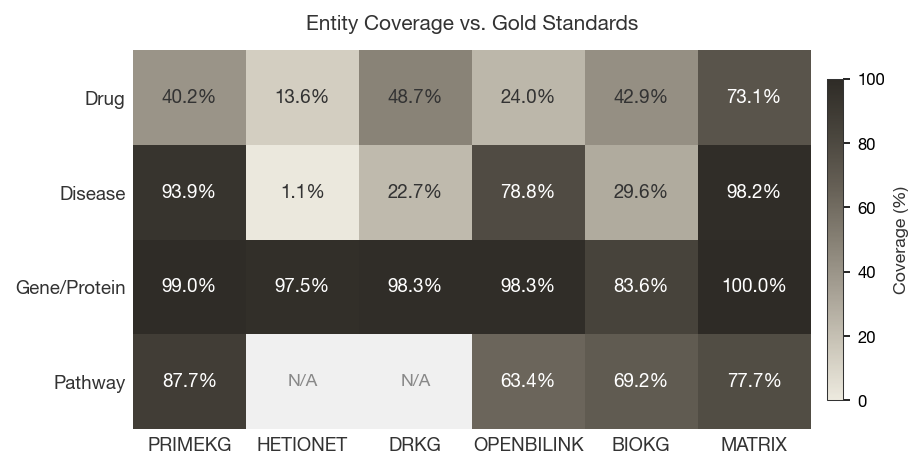

In [15]:
# Entity coverage heatmap - entity types x KGs
ENTITY_ORDER = [e for e in ['Drug', 'Disease', 'Gene/Protein', 'Pathway']
                if e in entity_summary['Entity Type'].values]

pivot = (entity_summary
         .pivot(index='Entity Type', columns='KG', values='Coverage (%)')
         .reindex(index=ENTITY_ORDER, columns=KG_NAMES))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
data, valid = pivot.values.astype(float), ~np.isnan(pivot.values)

# Valid data cells
im = ax.pcolormesh(np.where(valid, data, np.nan),
                   cmap=HEATMAP_CMAP, vmin=0, vmax=100,
                   edgecolors='none', linewidth=0, antialiased=False)
# N/A cells
na_data = np.where(~valid, 1, np.nan)
ax.pcolormesh(na_data,
              cmap=mcolors.ListedColormap(['#f0f0f0']), vmin=0, vmax=1,
              edgecolors='none', linewidth=0, antialiased=False)

ax.set_xticks([x + 0.5 for x in range(len(pivot.columns))])
ax.set_xticklabels([n.upper() for n in pivot.columns], fontsize=9, color=TEXT_COLOR)
ax.set_yticks([y + 0.5 for y in range(len(pivot.index))])
ax.set_yticklabels(pivot.index, fontsize=9, color=TEXT_COLOR)
ax.tick_params(length=0, which='both')
ax.grid(False, which='both')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

for i, entity in enumerate(pivot.index):
    for j, kg in enumerate(pivot.columns):
        val = pivot.loc[entity, kg]
        if pd.notna(val):
            ax.text(j + 0.5, i + 0.5, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if val >= 55 else TEXT_COLOR)
        else:
            ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                    fontsize=8.5, color='#888888', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Coverage (%)', fontsize=8.5, color=TEXT_COLOR)
ax.set_title('Entity Coverage vs. Gold Standards',
             fontsize=10, fontweight='bold', color=TEXT_COLOR, pad=10)

plt.tight_layout()
save_fig(fig, FIGS, '01_entity_coverage')
plt.show()


## 2. Relation Coverage

$$\text{Relation Coverage}_r = \frac{|\text{KG pairs}_r \cap \text{Gold pairs}_r|}{|\text{Gold pairs}_r|}$$

Relation names per KG come from `config.yaml`; unconfigured relations are N/A. Gold standards: drug–target (DrugBank, HGNC→Entrez), drug–disease (Open Targets, MONDO-normalised), drug–drug (DrugBank DDI, unordered).

In [16]:
# Relation helpers - edge filtering and pair extraction

def get_edges(kg: pd.DataFrame, rel_spec: dict) -> pd.DataFrame:
    """Filter edges by relation spec (keys: 'relation' or 'relations', optional 'display_relation')."""
    mask = (kg['relation'].isin(rel_spec['relations']) if 'relations' in rel_spec
            else kg['relation'] == rel_spec['relation'])
    if 'display_relation' in rel_spec:
        mask &= kg['display_relation'] == rel_spec['display_relation']
    return kg[mask]

def extract_pairs(kg: pd.DataFrame, rel_spec: dict,
                  normalise_disease: bool = False,
                  x_type_filter: Optional[str] = None,
                  y_type_filter: Optional[str] = None) -> set:
    """Return (x_id, y_id) pairs for a relation, stripping entity-type prefixes.

    normalise_disease maps y-side disease IDs to MONDO numeric via _to_mondo.
    """
    edges = get_edges(kg, rel_spec)
    if x_type_filter is not None:
        edges = edges[edges['x_type'] == x_type_filter]
    if y_type_filter is not None:
        edges = edges[edges['y_type'] == y_type_filter]

    x_ids = edges['x_id'].astype(str).map(_strip_prefix)
    y_ids = edges['y_id'].astype(str).map(_strip_prefix)
    if normalise_disease:
        y_ids = y_ids.map(_to_mondo)

    mask = x_ids.notna() & y_ids.notna()
    return set(zip(x_ids[mask], y_ids[mask]))


**Drug–target.** Gold standard: DrugBank drug–target pairs, filtered to approved and investigational compounds. DrugBank stores targets as HGNC gene symbols; UniProt human proteome mapping bridges to Entrez IDs. Each gold-standard pair is a `(DrugBank ID, Entrez ID)` tuple.

In [17]:
# Symbol -> Entrez mapping and drug-target gold standard
symbol_to_entrez = {
    sym.upper(): str(row['GeneID']).split(';')[0].strip()
    for _, row in uniprot.iterrows()
    if pd.notna(row['GeneID'])
    for sym in str(row.get('Gene Names', '')).split()
}

gold_drug_targets = {
    (row['drugbank_id'], entrez)
    for _, row in drugbank_relevant.iterrows()
    if pd.notna(row['target_genes'])
    for sym in str(row['target_genes']).split('|')
    if (entrez := symbol_to_entrez.get(sym.strip().upper()))
}


Gold standard - Drug-Target pairs: 13,430



In [18]:
# Drug-target coverage per KG
_NO_RESULT_DT = {
    'coverage_pct': float('nan'), 'overlap_n': float('nan'),
    'gold_n': len(gold_drug_targets), 'matched': set(),
    'unmatched': gold_drug_targets,
}

dt_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_target')
    if rel_spec is None:
        dt_results[kg_name] = _NO_RESULT_DT
        continue

    if kg_name == 'openbilink':
        emap      = ENTITY_TYPE_MAP[kg_name]
        edges     = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        gene_type = emap['Gene/Protein']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == gene_type)]
        rev = edges[(edges['x_type'] == gene_type) & (edges['y_type'] == drug_type)]

        def _obl_dt_pairs(drug_col, gene_col, df):
            drug_ids = df[drug_col].map(_obl_pc_to_db)
            gene_ids = df[gene_col].str.replace('NCBIGENE:', '', regex=False)
            valid    = drug_ids.notna() & gene_ids.notna()
            return set(zip(drug_ids[valid], gene_ids[valid]))

        obl_pairs = _obl_dt_pairs('x_id', 'y_id', fwd) | _obl_dt_pairs('y_id', 'x_id', rev)
        res = calc_coverage(obl_pairs, gold_drug_targets)

    elif kg_name == 'biokg':
        emap      = ENTITY_TYPE_MAP[kg_name]
        edges     = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        gene_type = emap['Gene/Protein']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == gene_type)]
        rev = edges[(edges['x_type'] == gene_type) & (edges['y_type'] == drug_type)]

        def _biokg_dt_pairs(drug_col, gene_col, df):
            drug_ids = df[drug_col].astype(str).map(_strip_prefix)
            gene_ids = df[gene_col].astype(str).map(
                lambda x: _uniprot_to_entrez.get(_strip_prefix(x)))
            valid    = drug_ids.notna() & gene_ids.notna()
            return set(zip(drug_ids[valid], gene_ids[valid]))

        biokg_pairs = _biokg_dt_pairs('x_id', 'y_id', fwd) | _biokg_dt_pairs('y_id', 'x_id', rev)
        res = calc_coverage(biokg_pairs, gold_drug_targets)

    else:
        res = calc_coverage(extract_pairs(data['kg'], rel_spec), gold_drug_targets)

    dt_results[kg_name] = res


primekg     :  70.0%  (9,398 / 13,430)
hetionet    :  29.6%  (3,971 / 13,430)
drkg        :  67.8%  (9,104 / 13,430)
openbilink  :  29.2%  (3,926 / 13,430)
biokg       :  70.6%  (9,487 / 13,430)
matrix      :  77.0%  (10,342 / 13,430)


**Drug–disease indication.** Gold standard: Open Targets drug–disease indications with MONDO IDs. Disease IDs in KGs are normalised to MONDO according to the per-KG `disease_id_scheme` in config: MONDO-native KGs match directly (splitting compound IDs on the configured separator); other KGs bridge via DOID/MESH→MONDO tables. Pairs without a resolvable MONDO ID (~16% of Open Targets) are excluded from the denominator.

In [19]:
# Drug-disease gold standard from Open Targets
ot_ind['combined_mondo'] = ot_ind['mondo_id'].fillna(ot_ind['mondo_id_mapped'])

ot_mondo = (
    ot_ind[
        ot_ind['combined_mondo'].notna() &
        ot_ind['drugbank_id'].isin(_db_all_ids)
    ].copy()
)

# Normalise combined_mondo to a bare integer string.
# The column can contain three formats depending on source:
#   (a) bare float:  7455.0   — pandas int column with NaNs upcast to float64
#   (b) prefixed:    MONDO:0007455  — string column from mondo_id_mapped
#   (c) bare int:    7455     — already clean
# Strategy: strip 'MONDO:' prefix first, then convert to float->int->str
# to eliminate trailing '.0', then lstrip leading zeros.
def _norm_mondo_id(v) -> str:
    s = str(v).strip().replace('MONDO:', '')
    try:
        return str(int(float(s))) if s not in ('', 'nan') else None
    except (ValueError, OverflowError):
        return None

ot_mondo['mondo_norm'] = ot_mondo['combined_mondo'].map(_norm_mondo_id)
ot_mondo = ot_mondo[ot_mondo['mondo_norm'].notna()]

gold_drug_disease = set(zip(ot_mondo['drugbank_id'].astype(str), ot_mondo['mondo_norm']))


Gold standard - Drug-Disease pairs: 27,935  (27,935/33,390 with MONDO IDs)



In [20]:
# Drug-disease coverage per KG
_NO_RESULT_DD = {
    'coverage_pct': float('nan'), 'overlap_n': float('nan'),
    'gold_n': len(gold_drug_disease), 'matched': set(),
    'unmatched': gold_drug_disease,
}

def _extract_drug_disease_pairs(kg: pd.DataFrame, kg_name: str, rel_spec: dict) -> set:
    """Extract (drugbank_id, mondo_norm) pairs for drug-disease relation.

    Non-MONDO KGs: use extract_pairs() with _to_mondo normalisation on the disease side.
    MONDO-native KGs: vectorised extraction with optional compound-ID splitting.
    """
    scheme = config['knowledge_graphs'][kg_name].get('disease_id_scheme', 'doid')
    if scheme != 'mondo':
        return extract_pairs(kg, rel_spec, normalise_disease=True)

    sep  = config['knowledge_graphs'][kg_name].get('disease_id_separator')
    emap = ENTITY_TYPE_MAP[kg_name]
    edges = get_edges(kg, rel_spec)
    fwd   = edges[(edges['x_type'] == emap['Drug'])    & (edges['y_type'] == emap['Disease'])]
    rev   = edges[(edges['x_type'] == emap['Disease']) & (edges['y_type'] == emap['Drug'])]

    pairs = set()
    # FIX: vectorised extraction replaces the slow iterrows() loop.
    for drug_col, dis_col, df in [('x_id', 'y_id', fwd), ('y_id', 'x_id', rev)]:
        if df.empty:
            continue
        drug_s = df[drug_col].astype(str)
        dis_s  = df[dis_col].astype(str)
        if sep:
            # Explode compound disease IDs (e.g. "12345|67890") into separate rows
            dis_exploded  = dis_s.str.split(sep).explode()
            drug_exploded = drug_s.loc[dis_exploded.index]
            dis_norm      = dis_exploded.str.strip().str.lstrip('0').replace({'': '0'})
        else:
            drug_exploded = drug_s
            dis_norm      = dis_s.str.strip().str.lstrip('0').replace({'': '0'})
        pairs.update(zip(drug_exploded, dis_norm))
    return pairs

dd_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_disease')
    if rel_spec is None:
        dd_results[kg_name] = _NO_RESULT_DD
        continue

    if kg_name == 'openbilink':
        emap      = ENTITY_TYPE_MAP[kg_name]
        edges     = get_edges(data['kg'], rel_spec)
        drug_type = emap['Drug']
        dis_type  = emap['Disease']
        fwd = edges[(edges['x_type'] == drug_type) & (edges['y_type'] == dis_type)]
        rev = edges[(edges['x_type'] == dis_type)  & (edges['y_type'] == drug_type)]

        def _obl_dd_pairs(drug_col, dis_col, df):
            drug_ids = df[drug_col].map(_obl_pc_to_db)
            dis_ids  = df[dis_col].astype(str).map(_to_mondo)
            valid    = drug_ids.notna() & dis_ids.notna()
            return set(zip(drug_ids[valid], dis_ids[valid]))

        obl_pairs = _obl_dd_pairs('x_id', 'y_id', fwd) | _obl_dd_pairs('y_id', 'x_id', rev)
        res = calc_coverage(obl_pairs, gold_drug_disease)
    else:
        res = calc_coverage(
            _extract_drug_disease_pairs(data['kg'], kg_name, rel_spec),
            gold_drug_disease)

    dd_results[kg_name] = res


primekg     :   7.7%  (2,152 / 27,935)
hetionet    :   1.8%  (504 / 27,935)
drkg        :   4.4%  (1,228 / 27,935)
openbilink  :   5.3%  (1,481 / 27,935)
biokg       :  11.4%  (3,190 / 27,935)
matrix      :  47.3%  (13,221 / 27,935)


**Drug–drug interaction.** Gold standard: DrugBank DDI pairs (unordered). KGs without a `drug_drug` relation configured in `config.yaml` are reported as N/A — this is appropriate when the KG encodes something other than clinical DDI (e.g. structural similarity) under that relation slot.

In [21]:
# Drug-drug interaction gold standard and coverage
#
# NOTE on denominator: _db_all_ids (all DrugBank statuses) is used here,
# consistent with DrugBank DDI data which spans approved, investigational,
# experimental, and withdrawn compounds. This is intentionally broader than
# gold_drugs (approved + investigational only) used for entity/drug-target
# coverage. The choice reflects that DDI annotations in DrugBank are not
# restricted to approved drugs. See Methods for discussion.

# FIX: vectorised construction replaces iterrows() over 1.4M pairs (~40s -> <1s)
import numpy as np
_ddi_mask = (
    drugbank_ddi['drug1_id'].isin(_db_all_ids) &
    drugbank_ddi['drug2_id'].isin(_db_all_ids)
)
_ddi_filt = drugbank_ddi[_ddi_mask][['drug1_id', 'drug2_id']].values
gold_ddi  = set(map(tuple, np.sort(_ddi_filt, axis=1).tolist()))

_NO_RESULT_DDI = {
    'coverage_pct': float('nan'), 'overlap_n': float('nan'),
    'gold_n': len(gold_ddi), 'matched': set(), 'unmatched': gold_ddi,
}

ddi_results = {}
for kg_name, data in kgs.items():
    rel_spec = KG_RELATIONS[kg_name].get('drug_drug')
    if rel_spec is None:
        ddi_results[kg_name] = _NO_RESULT_DDI
        continue
    res = calc_coverage(
        {tuple(sorted(p)) for p in extract_pairs(data['kg'], rel_spec)},
        gold_ddi)
    ddi_results[kg_name] = res


Gold standard - Drug-Drug pairs: 1,454,734

primekg     :  85.6%  (1,245,332 / 1,454,734)
hetionet    : N/A (no drug_drug relation in config)
drkg        :  83.2%  (1,209,737 / 1,454,734)
openbilink  : N/A (no drug_drug relation in config)
biokg       :  84.3%  (1,226,389 / 1,454,734)
matrix      :  66.9%  (972,831 / 1,454,734)


### Visualisation

  → Saved: 01_relation_coverage.pdf / .png


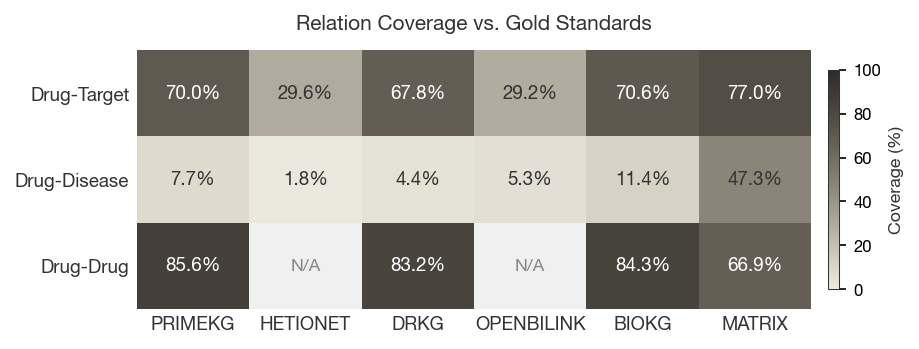

In [22]:
# Relation coverage heatmap - relation types x KGs (mirrors entity coverage heatmap style)
RELATION_RESULTS = {
    'Drug-Target':  dt_results,
    'Drug-Disease': dd_results,
    'Drug-Drug':    ddi_results,
}

relation_summary = pd.DataFrame([
    {'KG': kg_name, 'Relation': rel_label,
     'Coverage (%)': res['coverage_pct'],
     'Overlap': res['overlap_n'], 'Gold': res['gold_n']}
    for rel_label, results in RELATION_RESULTS.items()
    for kg_name, res in results.items()
])

RELATION_ORDER = list(RELATION_RESULTS.keys())

pivot_rel = (relation_summary
             .pivot(index='Relation', columns='KG', values='Coverage (%)')
             .reindex(index=RELATION_ORDER, columns=KG_NAMES))

fig, ax = plt.subplots(figsize=(6.5, 2.4))
data_rel = pivot_rel.values.astype(float)
valid_rel = ~np.isnan(data_rel)

im = ax.pcolormesh(np.where(valid_rel, data_rel, np.nan),
                   cmap=HEATMAP_CMAP, vmin=0, vmax=100,
                   edgecolors='none', linewidth=0, antialiased=False)
ax.pcolormesh(np.where(~valid_rel, 1, np.nan),
              cmap=mcolors.ListedColormap(['#f0f0f0']), vmin=0, vmax=1,
              edgecolors='none', linewidth=0, antialiased=False)

ax.set_xticks([x + 0.5 for x in range(len(pivot_rel.columns))])
ax.set_xticklabels([n.upper() for n in pivot_rel.columns], fontsize=9, color=TEXT_COLOR)
ax.set_yticks([y + 0.5 for y in range(len(pivot_rel.index))])
ax.set_yticklabels(pivot_rel.index, fontsize=9, color=TEXT_COLOR)
ax.tick_params(length=0, which='both')
ax.grid(False, which='both')
ax.invert_yaxis()
for spine in ax.spines.values():
    spine.set_visible(False)

for i, rel in enumerate(pivot_rel.index):
    for j, kg in enumerate(pivot_rel.columns):
        val = pivot_rel.loc[rel, kg]
        if pd.notna(val):
            ax.text(j + 0.5, i + 0.5, f'{val:.1f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if val >= 55 else TEXT_COLOR)
        else:
            ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                    fontsize=8.5, color='#888888', style='italic')

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Coverage (%)', fontsize=8.5, color=TEXT_COLOR)
ax.set_title('Relation Coverage vs. Gold Standards',
             fontsize=10, fontweight='bold', color=TEXT_COLOR, pad=10)

plt.tight_layout()
save_fig(fig, FIGS, '01_relation_coverage')
plt.show()


### Diagnostic: relation coverage gaps

Separates missing pairs into entity-absent, relation-not-curated, or ID-mapping failure, per relation type.

In [23]:
# Relation gap decomposition: why are pairs missing?
# For each missing gold pair (x, y), classify into:
#   - "both entities absent"  — neither x nor y in the KG
#   - "one entity absent"     — one of x/y not in the KG
#   - "relation not curated"  — both entities present but pair not linked
#
# Note: doid_to_mondo_all is now built from the full many-to-many reverse map
# (cell 7 fix), so kg_other_set for non-MONDO KGs is complete.

from IPython.display import display   # explicit display for DataFrames inside if-blocks

_REL_GOLD = {
    'Drug-Target':  gold_drug_targets,
    'Drug-Disease': gold_drug_disease,
    'Drug-Drug':    gold_ddi,
}

rel_gap_rows = []
for rel_label, results in RELATION_RESULTS.items():
    gold_pairs = _REL_GOLD[rel_label]
    for kg_name, res in results.items():
        if isinstance(res['overlap_n'], float) and math.isnan(res['overlap_n']):
            continue
        unmatched_pairs = res['unmatched']
        if not unmatched_pairs:
            continue

        kg_drug_set = entity_sets[kg_name].get('Drug', set())
        if rel_label == 'Drug-Target':
            kg_other_set = entity_sets[kg_name].get('Gene/Protein', set())
        elif rel_label == 'Drug-Disease':
            cfg = config['knowledge_graphs'][kg_name]
            if cfg.get('disease_id_scheme') == 'mondo':
                kg_other_set = entity_sets[kg_name].get('Disease', set())
            else:
                # Bridge DOID-normalised disease set to MONDO for comparison.
                # doid_to_mondo_all is now built from the full reverse map (cell 7).
                kg_other_set = set()
                for d in entity_sets[kg_name].get('Disease', set()):
                    kg_other_set.update(doid_to_mondo_all.get(d, []))
        else:  # Drug-Drug
            kg_other_set = kg_drug_set

        n_both_absent, n_one_absent, n_not_curated = 0, 0, 0
        for x, y in unmatched_pairs:
            x_in = x in kg_drug_set
            y_in = y in (kg_drug_set if rel_label == 'Drug-Drug' else kg_other_set)
            if not x_in and not y_in:
                n_both_absent += 1
            elif not x_in or not y_in:
                n_one_absent += 1
            else:
                n_not_curated += 1

        n_miss = len(unmatched_pairs)
        rel_gap_rows.append({
            'KG': kg_name, 'Relation': rel_label,
            'Missing': n_miss,
            'Both Absent': n_both_absent,
            'One Absent': n_one_absent,
            'Not Curated': n_not_curated,
        })

if rel_gap_rows:
    display(pd.DataFrame(rel_gap_rows).set_index(['KG', 'Relation']))  # FIX: explicit display


Relation gap decomposition

  primekg      / Drug-Target   :     4,032 missing
    Both absent                    0  (  0.0%)
    One absent                 1,970  ( 48.9%)
    Relation not curated       2,062  ( 51.1%)
  hetionet     / Drug-Target   :     9,459 missing
    Both absent                    3  (  0.0%)
    One absent                 8,099  ( 85.6%)
    Relation not curated       1,357  ( 14.3%)
  drkg         / Drug-Target   :     4,326 missing
    Both absent                    0  (  0.0%)
    One absent                 1,233  ( 28.5%)
    Relation not curated       3,093  ( 71.5%)
  openbilink   / Drug-Target   :     9,504 missing
    Both absent                    0  (  0.0%)
    One absent                 4,986  ( 52.5%)
    Relation not curated       4,518  ( 47.5%)
  biokg        / Drug-Target   :     3,943 missing
    Both absent                   18  (  0.5%)
    One absent                 1,853  ( 47.0%)
    Relation not curated       2,072  ( 52.5%)
  matrix    

,,Missing,Both Absent,One Absent,Not Curated
KG,Relation,,,,
primekg,Drug-Target,4032,0,1970,2062
hetionet,Drug-Target,9459,3,8099,1357
drkg,Drug-Target,4326,0,1233,3093
openbilink,Drug-Target,9504,0,4986,4518
biokg,Drug-Target,3943,18,1853,2072
matrix,Drug-Target,3088,0,2133,955
primekg,Drug-Disease,25783,1373,15672,8738
hetionet,Drug-Disease,27431,7158,16745,3528
drkg,Drug-Disease,26707,135,9514,17058


In [24]:
# Checkpoint - save scalar coverage results for downstream notebooks
CKPT_DIR = BASE / 'results' / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

def _scalar(res: dict) -> dict:
    """Extract scalar stats from a coverage result dict (strips large ID sets)."""
    ovl = res['overlap_n']
    pct = res['coverage_pct']
    return {
        'pct':     pct,
        'overlap': int(ovl) if not (isinstance(ovl, float) and math.isnan(ovl)) else None,
        'gold':    int(res['gold_n']),
    }

# Entity coverage (per eligible entity type, 0-1 scale)
entity_cov = {
    kg_name: {
        et: round(len(kg_set & GOLD_SETS[et]) / len(GOLD_SETS[et]), 4)
        for et, kg_set in sets.items()
        if et in GOLD_SETS and _eligible(kg_name, et)
    }
    for kg_name, sets in entity_sets.items()
}

# Relation coverage (per relation type, 0-1 scale)
relation_cov_raw = {
    kg: {
        'drug_target':  _scalar(dt_results[kg]),
        'drug_disease': _scalar(dd_results[kg]),
        'drug_drug':    _scalar(ddi_results[kg]),
    }
    for kg in KG_NAMES
}

# Shared types: present and non-NaN in ALL KGs (ensures fair cross-KG comparison)
SHARED_ENTITY_TYPES = sorted(
    set.intersection(*(set(entity_cov[kg].keys()) for kg in KG_NAMES))
)
SHARED_RELATION_TYPES = sorted([
    rtype for rtype in ['drug_target', 'drug_disease', 'drug_drug']
    if all(
        relation_cov_raw[kg][rtype]['pct'] is not None
        and not (isinstance(relation_cov_raw[kg][rtype]['pct'], float)
                 and math.isnan(relation_cov_raw[kg][rtype]['pct']))
        for kg in KG_NAMES
    )
])

sub_scores = {}
for kg in KG_NAMES:
    # FIX: explicit key access instead of dict.values() to avoid insertion-order dependency
    s_entity = round(float(np.mean([
        entity_cov[kg][et] for et in SHARED_ENTITY_TYPES
    ])), 4)

    # FIX: NaN guard — skip any type that somehow slipped through the shared-type filter
    rel_vals = [
        relation_cov_raw[kg][rt]['pct'] / 100.0
        for rt in SHARED_RELATION_TYPES
        if relation_cov_raw[kg][rt]['pct'] is not None
        and not math.isnan(relation_cov_raw[kg][rt]['pct'])
    ]
    s_relation = round(float(np.mean(rel_vals)) if rel_vals else float('nan'), 4)

    sub_scores[kg] = {
        'entity_coverage':   s_entity,
        'relation_coverage': s_relation,
    }

# FIX: explicit key access for summary mean — not dict.values()
summary_scores = {
    kg: round(float(np.mean([
        sub_scores[kg]['entity_coverage'],
        sub_scores[kg]['relation_coverage'],
    ])), 4)
    for kg in KG_NAMES
}

ckpt = {
    'summary_scores':        summary_scores,
    'sub_scores':            sub_scores,
    'entity_cov':            entity_cov,
    'relation_coverage':     relation_cov_raw,
    'shared_entity_types':   SHARED_ENTITY_TYPES,
    'shared_relation_types': SHARED_RELATION_TYPES,
    'kg_stats': {
        name: {
            'n_edges':     int(len(data['kg'])),
            'n_nodes':     int(len(data['nodes'])),
            'n_relations': int(data['kg']['relation'].nunique()),
        }
        for name, data in kgs.items()
    },
}

out = CKPT_DIR / '01_coverage.pkl'
with open(out, 'wb') as f:
    pickle.dump(ckpt, f)

print(f'\nCheckpoint saved: {out}')


## Dimension score

$$\text{Coverage} = \tfrac{1}{2}\left(\text{Entity Coverage} + \text{Relation Coverage}\right)$$

Each sub-metric averages over **shared types only** (present and evaluable in all KGs) for a fair comparison — e.g. Pathway is excluded (not all KGs use Reactome) and Drug–Drug is excluded (Hetionet lacks it). Full per-type detail stays in the checkpoint.

In [25]:
# Memory cleanup - free KG state before running notebook 02
# Without this, the kgs dict (~20 GB of pandas DataFrames) stays resident in
# the Jupyter kernel; nb02 then re-loads the same KGs on top, pushing peak
# memory past 150 GB and OOM-killing the kernel.
_to_free = [
    'kgs', 'entity_sets', 'membership',
    'dt_results', 'dd_results', 'ddi_results',
    'mondo_to_doid_all', 'doid_to_mondo_all',
    '_uniprot_to_entrez', '_obl_pc_to_db',
]
for _v in _to_free:
    try:
        del globals()[_v]
    except KeyError:
        pass
import gc
gc.collect()


Freed KG state from kernel memory.
